# Basic Classifiers: KNN
by AI@UCI
# ** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT

In [1]:
! pip install numpy pandas matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from itertools import product


## Loading the Iris Dataset


In [ ]:
# Load the iris dataset
IRIS_CSV = "../datasets/knn_iris_dataset.csv"
df = pd.read_csv(IRIS_CSV)
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Understanding the Dataset

The Iris dataset contains 150 samples of iris flowers with 4 features:
- **sepal_length**: Length of the sepal in cm
- **sepal_width**: Width of the sepal in cm  
- **petal_length**: Length of the petal in cm
- **petal_width**: Width of the petal in cm

And 3 target classes:
- **setosa**: Iris setosa
- **versicolor**: Iris versicolor
- **virginica**: Iris virginica


In [4]:
# Check dataset info
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nTarget classes:", df['species'].unique())
print("\nClass distribution:")
print(df['species'].value_counts())


Dataset shape: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Target classes: ['setosa' 'versicolor' 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Data Preprocessing


In [5]:
# Convert species names to numeric labels
species_to_int = {s: i for i, s in enumerate(sorted(df["species"].unique()))}
int_to_species = {v: k for k, v in species_to_int.items()}

print("Species to integer mapping:", species_to_int)
print("Integer to species mapping:", int_to_species)


Species to integer mapping: {'setosa': 0, 'versicolor': 1, 'virginica': 2}
Integer to species mapping: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


In [6]:
# Separate features (X) and target (y)
y = df["species"].map(species_to_int).values.astype(int)
X = df.drop(columns=["species"]).values.astype(float)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", df.drop(columns=["species"]).columns.tolist())


Features shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


## Train-Test Split


In [7]:
def stratified_split(X, y, train_ratio=0.8, seed=42):
    """
    Create a stratified train-test split that maintains class proportions.
    """
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y))
    train_idx, test_idx = [], []
    
    for cls in np.unique(y):
        cls_idx = indices[y == cls]
        rng.shuffle(cls_idx)
        split = int(train_ratio * len(cls_idx))
        train_idx.extend(cls_idx[:split])
        test_idx.extend(cls_idx[split:])
    
    return np.array(train_idx), np.array(test_idx)


In [8]:
# Split the data
train_idx, test_idx = stratified_split(X, y, train_ratio=0.8, seed=42)
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")


Training set: 120 samples
Test set: 30 samples
Training class distribution: [40 40 40]
Test class distribution: [10 10 10]


## KNN Implementation from Scratch


### KNN Class Definition

The KNN algorithm works by:
1. **Fit**: Store the training data (no actual training needed)
2. **Predict**: For each test point, find the k nearest neighbors and predict the majority class
3. **Distance**: Use Euclidean distance to measure similarity between points


In [9]:
class KNN:
    def __init__(self, k=5):
        """
        Initialize KNN classifier.
        
        Parameters:
        k (int): Number of nearest neighbors to consider
        """
        self.k = k
        self.X = None
        self.y = None

    def fit(self, X, y):
        """
        Store the training data.
        
        Parameters:
        X: Training features
        y: Training labels
        """
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=int)

    @staticmethod
    def _euclidean(a, b):
        """
        Calculate Euclidean distance between points a and b.
        
        Parameters:
        a: First point (can be array of points)
        b: Second point
        
        Returns:
        Distance(s) between a and b
        """
        return np.sqrt(np.sum((a - b) ** 2, axis=1))

    def _predict_one(self, x):
        """
        Predict the class for a single data point.
        
        Parameters:
        x: Single data point to classify
        
        Returns:
        Predicted class label
        """
        # Calculate distances to all training points
        dists = self._euclidean(self.X, x)
        
        # Get k nearest neighbors
        k = min(self.k, len(dists))
        idx = np.argpartition(dists, k-1)[:k]
        labels = self.y[idx]
        
        # Return majority class
        counts = np.bincount(labels, minlength=self.y.max()+1)
        return int(np.argmax(counts))

    def predict(self, X):
        """
        Predict classes for multiple data points.
        
        Parameters:
        X: Array of data points to classify
        
        Returns:
        Array of predicted class labels
        """
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X], dtype=int)

    def score(self, X, y):
        """
        Calculate accuracy score.
        
        Parameters:
        X: Test features
        y: True labels
        
        Returns:
        Accuracy score (0-1)
        """
        preds = self.predict(X)
        return float(np.mean(preds == y))


## Training and Testing the KNN Model


In [10]:
    @staticmethod
    def _euclidean(a, b):
        """
        Calculate Euclidean distance between points a and b.
        
        Parameters:
        a: First point (can be array of points)
        b: Second point
        
        Returns:
        Distance(s) between a and b
        """
        return np.sqrt(np.sum((a - b) ** 2, axis=1))


In [11]:
# Train KNN model with k=5
knn = KNN(k=5)
knn.fit(X_train, y_train)

# Test the model
accuracy = knn.score(X_test, y_test)
print(f"Test accuracy (k=5): {accuracy:.3f}")


Test accuracy (k=5): 0.967


## Model Evaluation


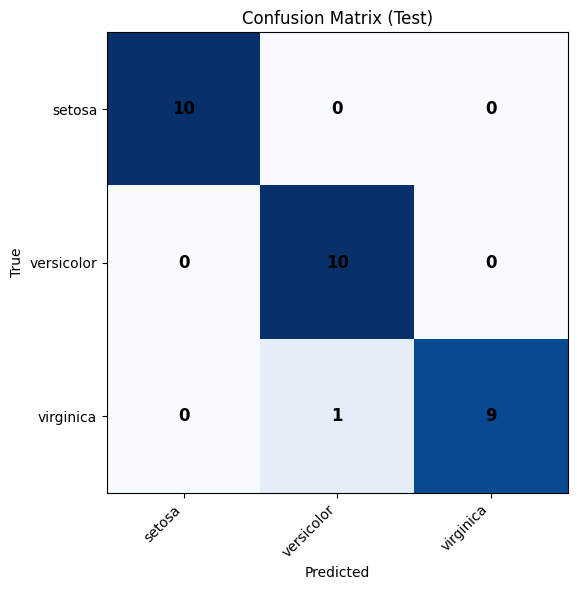

In [12]:
# Make predictions on test set
y_pred = knn.predict(X_test)

# Create confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels):
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap='Blues')
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(ticks=np.arange(n), labels=labels, rotation=45, ha="right")
    plt.yticks(ticks=np.arange(n), labels=labels)
    for (i, j) in product(range(n), range(n)):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display confusion matrix
labels = [int_to_species[i] for i in range(len(species_to_int))]
plot_confusion_matrix(y_test, y_pred, labels)


## Decision Boundary Visualization


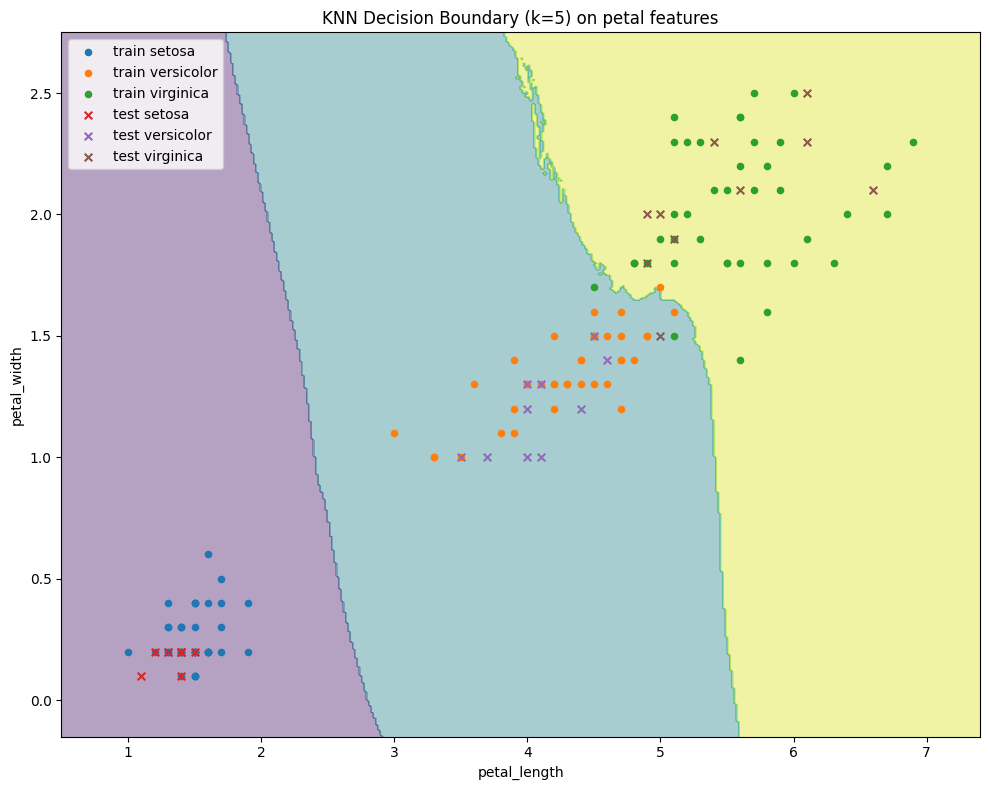

In [13]:
# Create decision boundary plot using only petal features (2D visualization)
def plot_decision_boundary(knn, X_train, y_train, X_test, y_test, int_to_species, feat_x=2, feat_y=3):
    X_all = np.vstack([X_train, X_test])
    x_min, x_max = X_all[:, feat_x].min() - 0.5, X_all[:, feat_x].max() + 0.5
    y_min, y_max = X_all[:, feat_y].min() - 0.25, X_all[:, feat_y].max() + 0.25
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    for cls in np.unique(y_train):
        mask = y_train == cls
        plt.scatter(X_train[mask, feat_x], X_train[mask, feat_y], label=f"train {int_to_species[cls]}", s=20)
    for cls in np.unique(y_test):
        mask = y_test == cls
        plt.scatter(X_test[mask, feat_x], X_test[mask, feat_y], marker="x", label=f"test {int_to_species[cls]}", s=30)
    plt.xlabel("petal_length")
    plt.ylabel("petal_width")
    plt.title(f"KNN Decision Boundary (k={knn.k}) on petal features")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# Train 2D KNN for visualization (using only petal features)
knn_2d = KNN(k=5)
knn_2d.fit(X_train[:, [2, 3]], y_train)

# Plot decision boundary
plot_decision_boundary(knn_2d, X_train, y_train, X_test, y_test, int_to_species, feat_x=2, feat_y=3)


## Testing Different Values of k


Testing different values of k:
k=1: Accuracy = 0.967
k=3: Accuracy = 0.967
k=5: Accuracy = 0.967
k=7: Accuracy = 0.967
k=10: Accuracy = 0.967


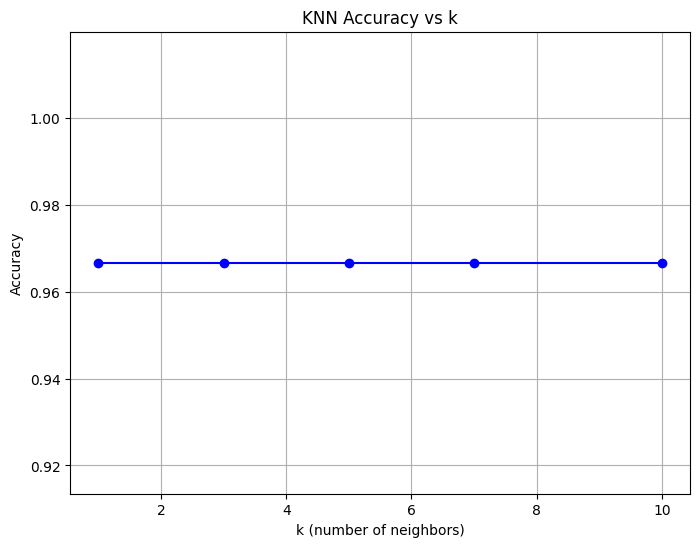

In [14]:
# Test different values of k
k_values = [1, 3, 5, 7, 10]
accuracies = []

print("Testing different values of k:")
for k in k_values:
    knn_test = KNN(k=k)
    knn_test.fit(X_train, y_train)
    acc = knn_test.score(X_test, y_test)
    accuracies.append(acc)
    print(f"k={k}: Accuracy = {acc:.3f}")

# Plot accuracy vs k
plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracies, 'bo-')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.grid(True)
plt.show()


## Summary

In this notebook, we successfully implemented the K-Nearest Neighbors algorithm from scratch and applied it to the Iris dataset. Key takeaways:

1. **KNN is a simple but effective algorithm** that classifies based on the majority class of k nearest neighbors
2. **Distance metric matters** - we used Euclidean distance to measure similarity
3. **Choice of k affects performance** - too small k can lead to overfitting, too large k can lead to underfitting
4. **Visualization helps** - decision boundaries and confusion matrices provide insights into model behavior
5. **Stratified splitting** ensures balanced train/test sets

The implementation achieved high accuracy on the Iris dataset, demonstrating the effectiveness of the KNN algorithm for this classification task.
